**TASK 3:** *FUTURE INTERNS*

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.
Path to dataset files: /kaggle/input/ecommerce-behavior-data-from-multi-category-store


In [ ]:
#IMPORT DATASET and begin clesning before anything
import pandas as pd
import numpy as np
import os
#let us bring the dataset into the ide
process_data = pd.read_csv(os.path.join(path, '2019-Oct.csv'))

# Take a quick look
print(process_data.shape)
process_data.head()


(42448764, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [ ]:
process_data.info() #to see all columns and what type of variable exists as their values:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


In [ ]:
# Group by session and check which event types occurred
session_events = process_data.groupby('user_session')['event_type'].apply(list).reset_index()

# Flag each stage
session_events['viewed'] = session_events['event_type'].apply(lambda x: 'view' in x)
session_events['added_to_cart'] = session_events['event_type'].apply(lambda x: 'cart' in x)
session_events['purchased'] = session_events['event_type'].apply(lambda x: 'purchase' in x)

In [ ]:
# Total numbers
total_sessions = len(session_events)
viewed = session_events['viewed'].sum()
cart = session_events['added_to_cart'].sum()
purchased_total = session_events['purchased'].sum()

# Only sessions that had both cart and purchase
cart_and_purchase = session_events[ session_events['added_to_cart'] & session_events['purchased'] ]
purchased_via_cart = len(cart_and_purchase)

# Purchase among cart-adders
cart_to_purchase_rate = purchased_via_cart / cart * 100

# Direct purchases (no cart)
direct_purchase = purchased_total - purchased_via_cart

# Overall conversion (any purchase / all sessions)
overall_rate = purchased_total / total_sessions * 100

# Rates for report
view_rate = viewed / total_sessions * 100
cart_rate = cart / viewed * 100   # view → cart

print(f"Sessions: {total_sessions}")
print(f"Viewed product: {viewed} ({view_rate:.1f}%)")
print(f"Added to cart:  {cart} ({cart_rate:.1f}% of viewers)")
print(f"Purchased (via cart): {purchased_via_cart} ({cart_to_purchase_rate:.1f}% of cart-adders)")
print(f"Purchased (total):    {purchased_total} ({overall_rate:.1f}% of all sessions)")
print(f"Direct purchases (no cart): {direct_purchase}")

Sessions: 9244421
Viewed product: 9242653 (100.0%)
Added to cart:  573097 (6.2% of viewers)
Purchased (via cart): 291861 (50.9% of cart-adders)
Purchased (total):    629560 (6.8% of all sessions)
Direct purchases (no cart): 337699


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y = ["Sessions", "Viewed Product", "Added to Cart", "Purchased (via cart)"],
    x = [total_sessions, viewed, cart, purchased_via_cart],
    textinfo = "value+percent initial"
))
fig.update_layout(title="E‑commerce Conversion Funnel (cart path)")
fig.write_html("funnel_ecommerce.html")   # save for report
fig.show()
#display the funnel

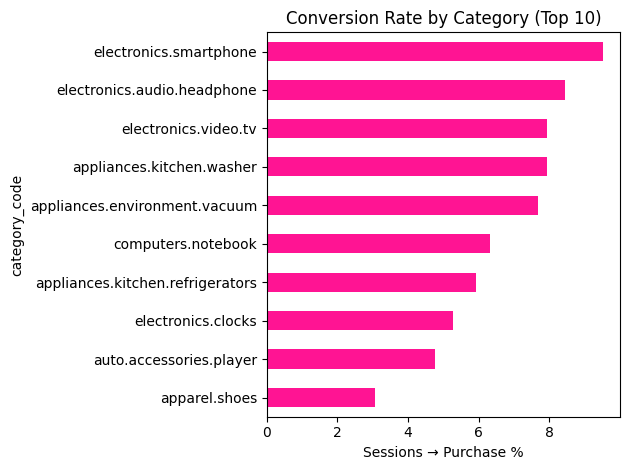

In [ ]:
import matplotlib.pyplot as plt
# Merge category back to session_events (using the first category in each session)
session_catergory = process_data.groupby('user_session')['category_code'].first().reset_index()
session_events = session_events.merge(session_catergory, on='user_session', how='left')

# Compute conversion (any purchase) for top categories by volume
catergories_top = session_events['category_code'].value_counts().head(10).index
catergory = session_events[session_events['category_code'].isin(catergories_top)].groupby('category_code').agg(
    sessions=('purchased', 'count'),
    purchases=('purchased', 'sum')
)
catergory['conversion'] = catergory['purchases'] / catergory['sessions'] * 100

# Horizontal bar chart
catergory['conversion'].sort_values().plot(kind='barh', color='deeppink')
plt.title('Conversion Rate by Category (Top 10)')
plt.xlabel('Sessions → Purchase %')
plt.tight_layout()
plt.savefig('category_conversion.png')
plt.show()

In [ ]:
#we need drop-off numbers:
view_after = viewed - cart
cart_after = cart - purchased_via_cart
purchase_after = purchased_total - direct_purchase
#
print("Drop-off:")
print(f"View → Cart: {view_after} lost ({view_after/viewed*100:.1f}% of viewers)")
print(f"Cart → Purchase: {cart_after} lost ({cart_after/cart*100:.1f}% of cart-adders)")
print(f"Direct purchases (bypassed cart): {direct_purchase}")

Drop-off:
View → Cart: 8669556 lost (93.8% of viewers)
Cart → Purchase: 281236 lost (49.1% of cart-adders)
Direct purchases (bypassed cart): 337699
